<a href="https://colab.research.google.com/github/s24118-ui/ASI/blob/main/Projekt_ASI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/ASI')

df = pd.read_csv('data.csv', sep=',')
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             10

/tmp/ipykernel_9206/1797980452.py:10: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv', sep=',')


In [11]:
print(f"Number of unique Customer_ID values: {df['Customer_ID'].nunique()}")
duplicate_customer_ids = df[df.duplicated(subset=['Customer_ID'], keep=False)]

Number of unique Customer_ID values: 12500


# Trzeba będzie grupować żeby ID klientów nie powtarzało się w obu grupach train / test

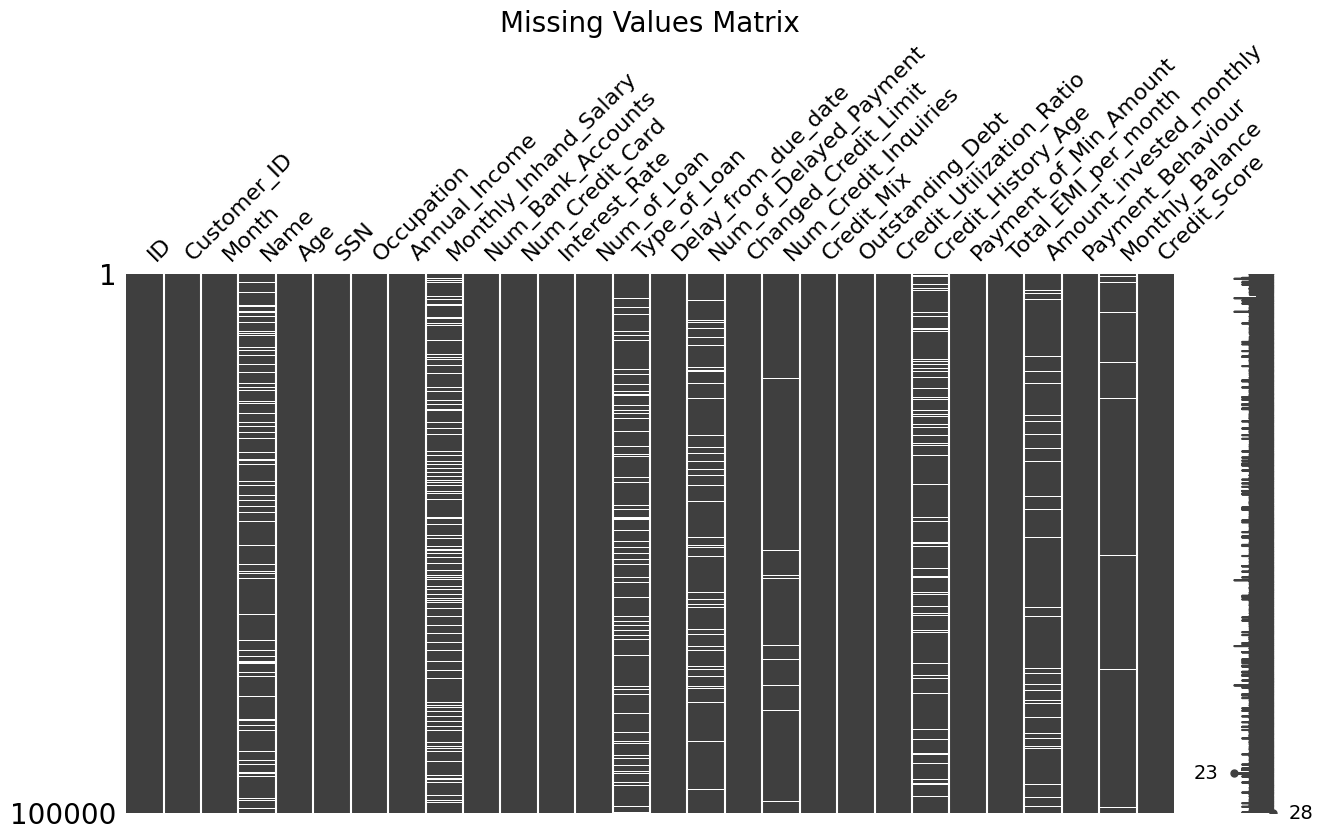

In [12]:
msno.matrix(df, figsize=(15, 7))
plt.title('Missing Values Matrix', fontsize=20)
plt.show()

In [13]:
display(df.head(20))

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,...,Good,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28_,004-07-5839,_______,34847.84,3037.986667,2,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good


Now, let's address the missing `Monthly_Inhand_Salary` values by grouping by `Customer_ID`. We will fill the missing salaries for a customer with a non-missing salary value available for that same customer. After this, we will recheck the `df.info()` to see the improvement in data completeness.

In [14]:
df['Monthly_Inhand_Salary'] = df.groupby('Customer_ID')['Monthly_Inhand_Salary'].transform(lambda x: x.ffill().bfill())

df.info()
display(df.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,...,Good,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28_,004-07-5839,_______,34847.84,3037.986667,2,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good


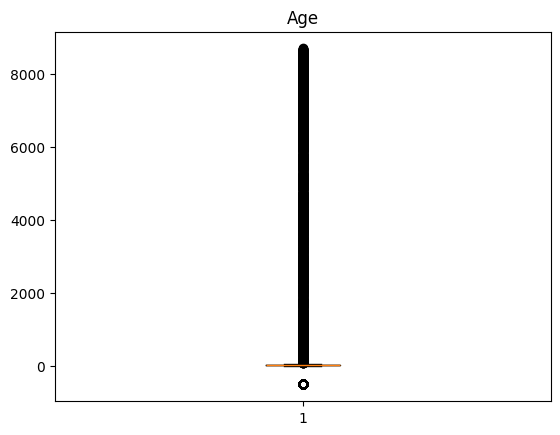

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

plt.boxplot(df['Age'].dropna())
plt.title("Age")
plt.show()

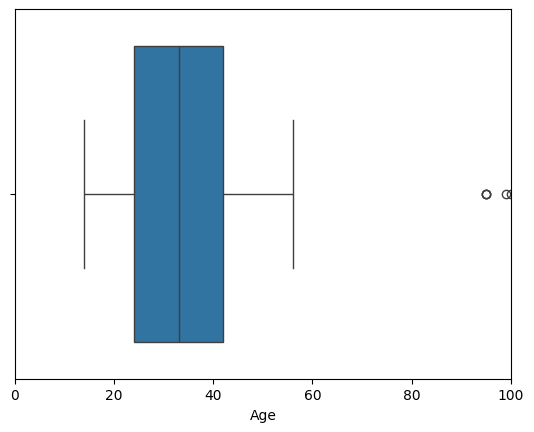

In [16]:
sns.boxplot(x=df["Age"])
plt.xlim(0, 100)
plt.show()

In [17]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].apply(lambda x: x if 0 <= x <= 90 else pd.NA)

df['Age'] = df.groupby('Customer_ID')['Age'].transform(lambda x: x.ffill().bfill())

print(df['Age'].describe())

/tmp/ipykernel_9206/1604008595.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Age'] = df.groupby('Customer_ID')['Age'].transform(lambda x: x.ffill().bfill())


count    100000.00000
mean         33.30638
std          10.76514
min          14.00000
25%          24.00000
50%          33.00000
75%          42.00000
max          56.00000
Name: Age, dtype: float64


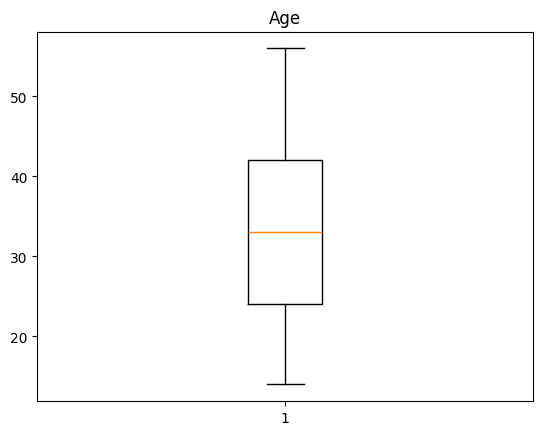

In [18]:
plt.boxplot(df['Age'])
plt.title("Age")
plt.show()

In [19]:
nan_age_count = df['Age'].isnull().sum()
print(f"{nan_age_count}")

0


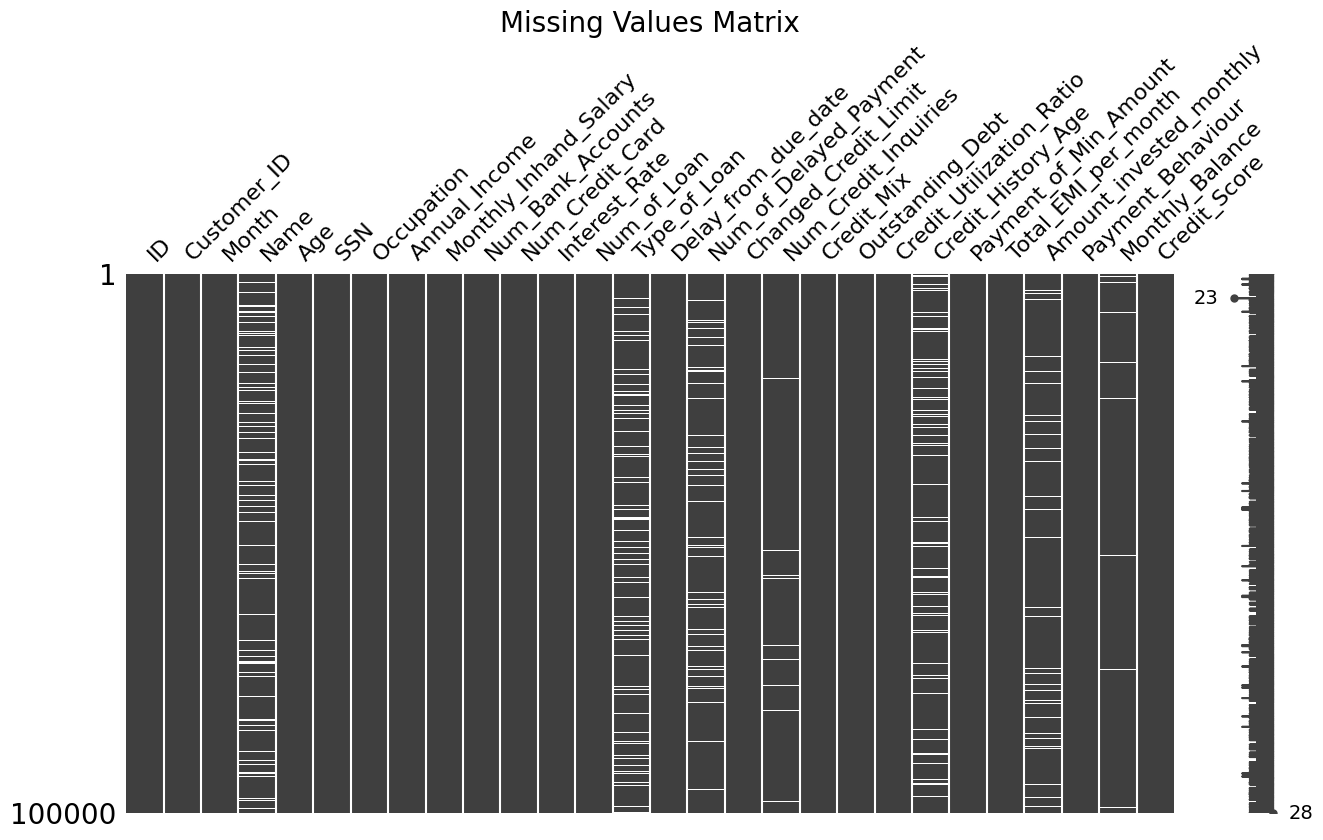

In [20]:
msno.matrix(df, figsize=(15, 7))
plt.title('Missing Values Matrix', fontsize=20)
plt.show()

In [21]:
pd.set_option('display.max_columns', None)
display(df.head(50))

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",8,4,9.27,4.0,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,8_,11.27,4.0,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good
7,0x1609,CUS_0xd40,August,NaN,23.0,#F%$D@*&8,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,6,11.27,4.0,Good,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28.0,004-07-5839,_______,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,3,4,5.42,2.0,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28.0,004-07-5839,Teacher,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,7,1,7.42,2.0,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good


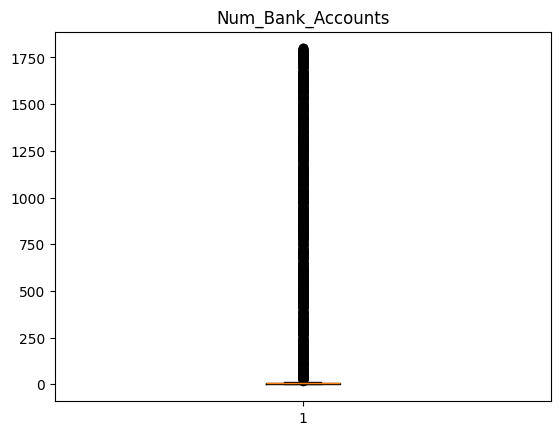

In [22]:
plt.boxplot(df['Num_Bank_Accounts'])
plt.title("Num_Bank_Accounts")
plt.show()

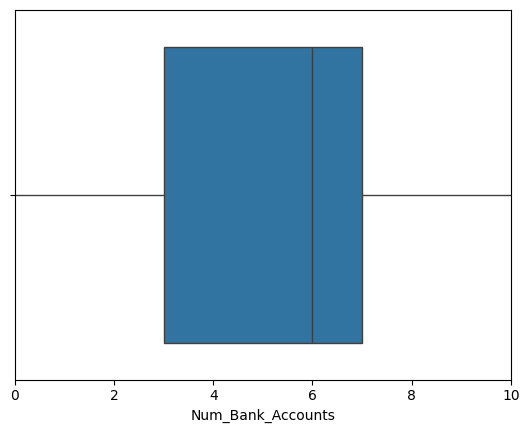

In [23]:
sns.boxplot(x=df["Num_Bank_Accounts"])
plt.xlim(0, 10)
plt.show()

In [24]:
negative_bank_accounts = df[df['Num_Bank_Accounts'] < 0]
print(negative_bank_accounts)

            ID Customer_ID     Month            Name   Age          SSN  \
30330   0xc7b8  CUS_0x4f2a     March       Margaretf  39.0  807-03-5415   
30331   0xc7b9  CUS_0x4f2a     April       Margaretf  40.0    #F%$D@*&8   
30332   0xc7ba  CUS_0x4f2a       May       Margaretf  40.0  807-03-5415   
30333   0xc7bb  CUS_0x4f2a      June       Margaretf  40.0  807-03-5415   
30334   0xc7bc  CUS_0x4f2a      July       Margaretf  40.0  807-03-5415   
30335   0xc7bd  CUS_0x4f2a    August       Margaretf  40.0  807-03-5415   
43689  0x115ff  CUS_0xa878  February  Douwe Miedemaz  54.0  300-54-4627   
43690  0x11600  CUS_0xa878     March  Douwe Miedemaz  54.0  300-54-4627   
43691  0x11601  CUS_0xa878     April  Douwe Miedemaz  54.0  300-54-4627   
43692  0x11602  CUS_0xa878       May  Douwe Miedemaz  54.0  300-54-4627   
43693  0x11603  CUS_0xa878      June  Douwe Miedemaz  54.0  300-54-4627   
43694  0x11604  CUS_0xa878      July  Douwe Miedemaz  54.0  300-54-4627   
43695  0x11605  CUS_0xa87

In [25]:
print(f"{len(negative_bank_accounts)}")

21


In [26]:
df = df[df['Num_Bank_Accounts'] >= 0]

In [27]:
weird_bank_accounts = df[df['Num_Bank_Accounts'] > 10]
print(f"{len(weird_bank_accounts)}")

1324


In [28]:
import numpy as np
df.loc[df['Num_Bank_Accounts'] > 10, 'Num_Bank_Accounts'] = np.nan
df.loc[df['Num_Bank_Accounts'] < 0, 'Num_Bank_Accounts'] = np.nan

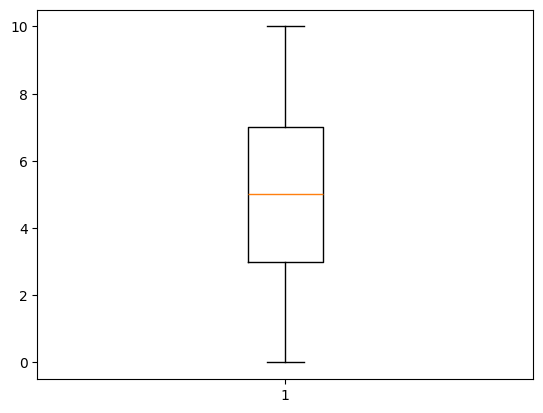

In [29]:
plt.boxplot(df['Num_Bank_Accounts'].dropna())
plt.show()

In [30]:
print(df['Num_Bank_Accounts'].describe())

count    98655.000000
mean         5.368466
std          2.592011
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: Num_Bank_Accounts, dtype: float64


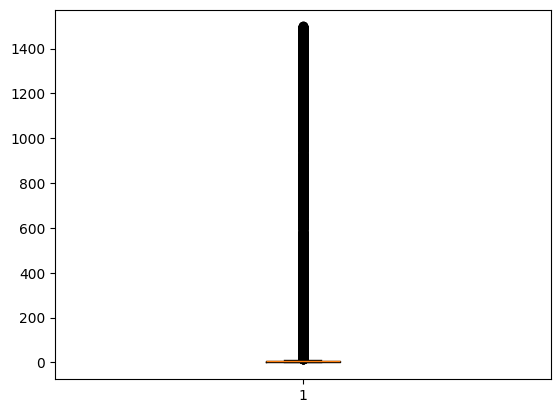

In [31]:
plt.boxplot(df['Num_Credit_Card'].dropna())
plt.show()

In [32]:
count = (df['Num_Credit_Card'] > 20).sum()
print(count)

2262


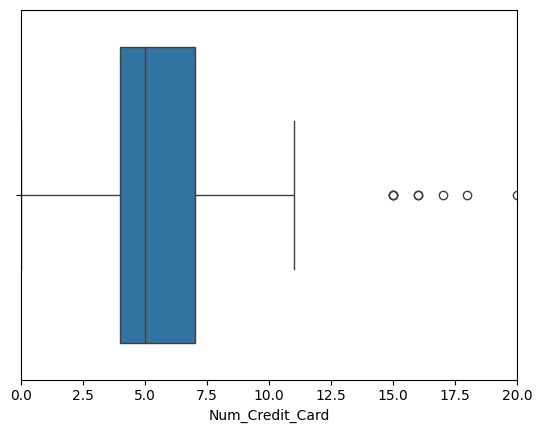

In [33]:
sns.boxplot(x=df["Num_Credit_Card"])
plt.xlim(0, 20)
plt.show()

In [34]:
df.loc[df['Num_Credit_Card'] > 13, 'Num_Credit_Card'] = np.nan

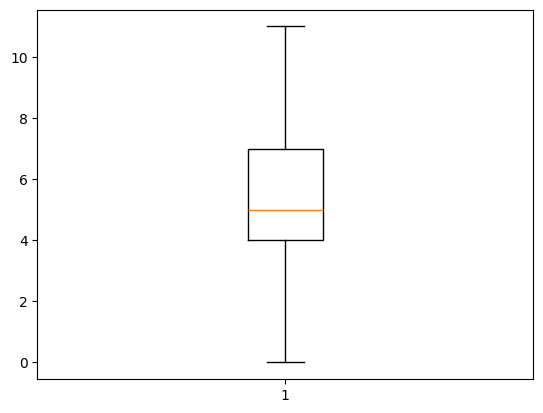

In [35]:
plt.boxplot(df['Num_Credit_Card'].dropna())
plt.show()

In [36]:
count = (df['Num_Credit_Card']).isnull().sum()
print(count)

2270


In [37]:
df['Num_Bank_Accounts'] = df.groupby('Customer_ID')['Num_Bank_Accounts'].transform(lambda x: x.ffill().bfill())
print(f"{df['Num_Bank_Accounts'].isnull().sum()}")

0


In [38]:
df['Num_Credit_Card'] = df.groupby('Customer_ID')['Num_Credit_Card'].transform(lambda x: x.ffill().bfill())
print(f"{df['Num_Credit_Card'].isnull().sum()}")

0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99979 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        99979 non-null  object 
 1   Customer_ID               99979 non-null  object 
 2   Month                     99979 non-null  object 
 3   Name                      89997 non-null  object 
 4   Age                       99979 non-null  float64
 5   SSN                       99979 non-null  object 
 6   Occupation                99979 non-null  object 
 7   Annual_Income             99979 non-null  object 
 8   Monthly_Inhand_Salary     99979 non-null  float64
 9   Num_Bank_Accounts         99979 non-null  float64
 10  Num_Credit_Card           99979 non-null  float64
 11  Interest_Rate             99979 non-null  int64  
 12  Num_of_Loan               99979 non-null  object 
 13  Type_of_Loan              88578 non-null  object 
 14  Delay_from_

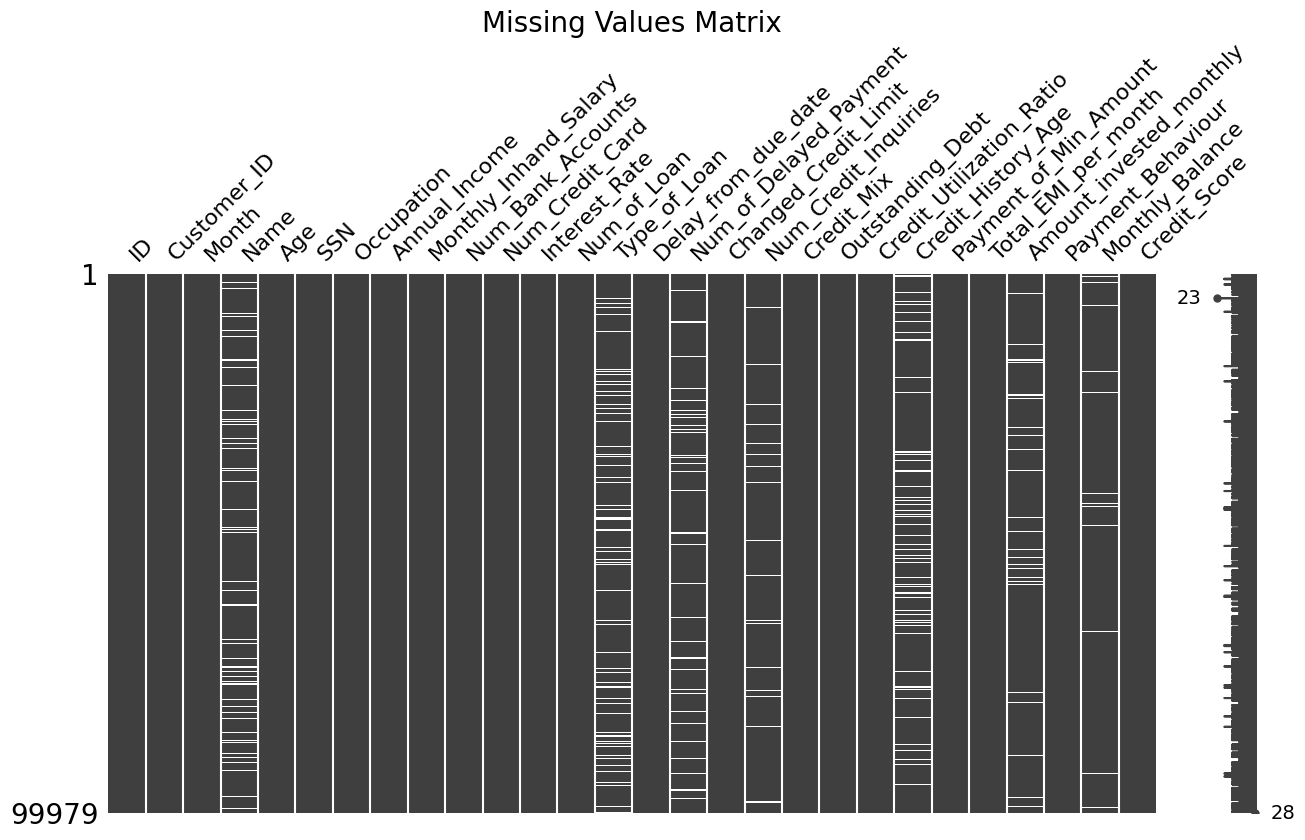

In [40]:
msno.matrix(df, figsize=(15, 7))
plt.title('Missing Values Matrix', fontsize=20)
plt.show()

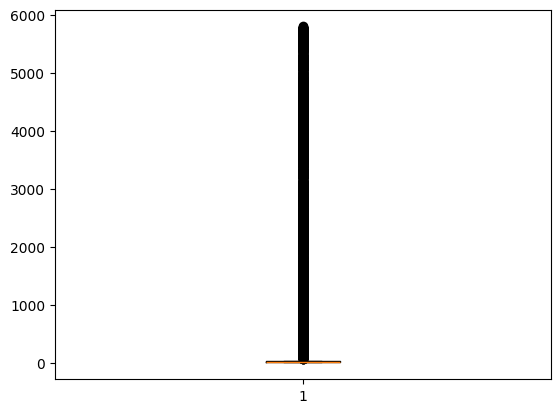

In [41]:
plt.boxplot(df['Interest_Rate'].dropna())
plt.show()

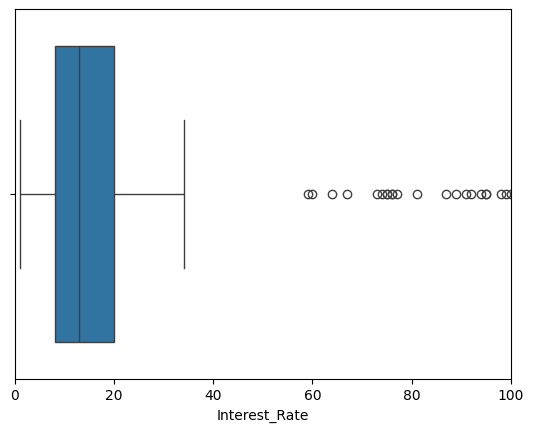

In [50]:
sns.boxplot(x=df["Interest_Rate"])
plt.xlim(0, 100)
plt.show()

In [51]:
interest_rate_gt_50 = df[df['Interest_Rate'] > 40]
print(f"{len(interest_rate_gt_50)}")

2034


In [52]:
print(df['Interest_Rate'].describe())

count    99979.000000
mean        72.480271
std        466.470569
min          1.000000
25%          8.000000
50%         13.000000
75%         20.000000
max       5797.000000
Name: Interest_Rate, dtype: float64


In [54]:
df.loc[df['Interest_Rate'] > 40, 'Interest_Rate'] = np.nan
df['Interest_Rate'] = df.groupby('Customer_ID')['Interest_Rate'].transform(lambda x: x.ffill().bfill())

In [55]:
print(df['Interest_Rate'].describe())
print(f"{df['Interest_Rate'].isnull().sum()}")

count    99979.000000
mean        14.534142
std          8.741009
min          1.000000
25%          7.000000
50%         13.000000
75%         20.000000
max         34.000000
Name: Interest_Rate, dtype: float64
0


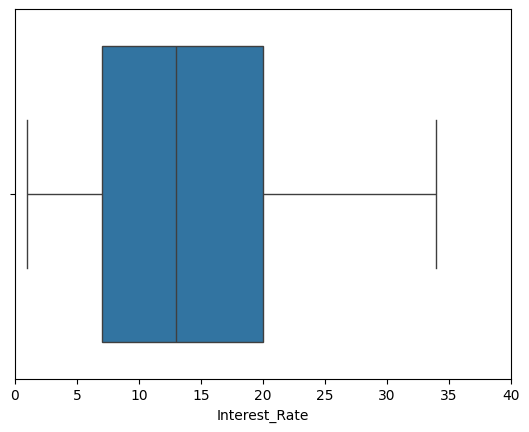

In [57]:
sns.boxplot(x=df["Interest_Rate"])
plt.xlim(0, 40)
plt.show()

count     99979
unique      434
top           3
freq      14382
Name: Num_of_Loan, dtype: object


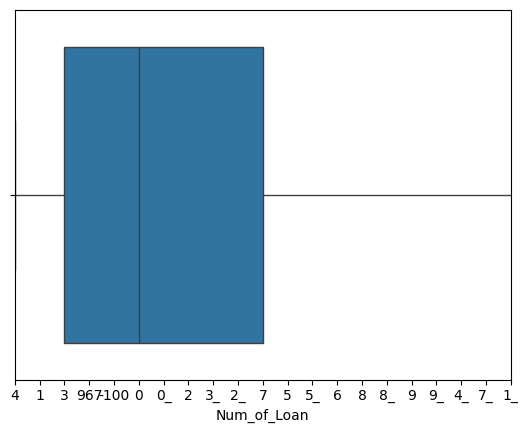

In [65]:
print(df['Num_of_Loan'].describe())
sns.boxplot(x=df["Num_of_Loan"])
plt.xlim(0, 20)
plt.show()


In [66]:
df['Num_of_Loan'] = df['Num_of_Loan'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['Num_of_Loan'] = pd.to_numeric(df['Num_of_Loan'], errors='coerce')
df['Num_of_Loan'] = df.groupby('Customer_ID')['Num_of_Loan'].transform(lambda x: x.ffill().bfill())

print(df['Num_of_Loan'].describe())
print(f"{df['Num_of_Loan'].isnull().sum()}")

count    99979.000000
mean        10.762950
std         61.795632
min          0.000000
25%          2.000000
50%          3.000000
75%          6.000000
max       1496.000000
Name: Num_of_Loan, dtype: float64
0


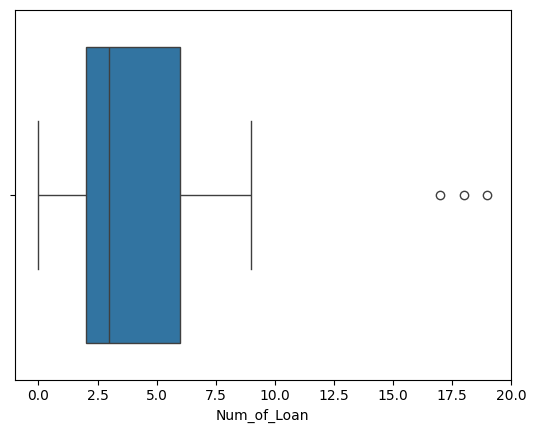

In [69]:
sns.boxplot(x=df["Num_of_Loan"])
plt.xlim(-1, 20)
plt.show()

In [70]:
negative_loans = df[df['Num_of_Loan'] < 0]
print(f"{len(negative_loans)}")
weird_loans = df[df['Num_of_Loan'] >15]
print(f"{len(weird_loans)}")

0
4347


In [71]:
df.loc[df['Num_of_Loan'] > 15, 'Num_of_Loan'] = np.nan
df['Num_of_Loan'] = df.groupby('Customer_ID')['Num_of_Loan'].transform(lambda x: x.ffill().bfill())

weird_loans = df[df['Num_of_Loan'] >15]
print(f"{len(weird_loans)}")

0


In [72]:
print(df['Type_of_Loan'].describe())

count             88578
unique             6260
top       Not Specified
freq               1408
Name: Type_of_Loan, dtype: object


In [73]:
top_50_loan_types = df['Type_of_Loan'].value_counts().head(50)
print(top_50_loan_types)

Type_of_Loan
Not Specified                                           1408
Credit-Builder Loan                                     1280
Personal Loan                                           1272
Debt Consolidation Loan                                 1264
Student Loan                                            1236
Payday Loan                                             1200
Mortgage Loan                                           1176
Auto Loan                                               1152
Home Equity Loan                                        1136
Personal Loan, and Student Loan                          320
Not Specified, and Payday Loan                           272
Mortgage Loan, and Home Equity Loan                      264
Student Loan, and Payday Loan                            256
Credit-Builder Loan, and Not Specified                   248
Student Loan, and Credit-Builder Loan                    248
Payday Loan, and Debt Consolidation Loan                 240
Payday Loan

In [74]:
filled_loans = df['Type_of_Loan'].fillna('Not Specified')

def get_unique_loan_types(loan_string):
    loan_string = loan_string.replace(' and ', ', ')
    types = [t.strip() for t in loan_string.split(',') if t.strip()]
    return types

all_loan_types = filled_loans.apply(get_unique_loan_types).explode()

unique_loan_types_array = all_loan_types.unique()

print("Array of all unique loan types:")
print(unique_loan_types_array)
print(f"Total unique loan types found: {len(unique_loan_types_array)}")

Array of all unique loan types:
['Auto Loan' 'Credit-Builder Loan' 'Personal Loan' 'Home Equity Loan'
 'Not Specified' 'Mortgage Loan' 'Student Loan' 'Debt Consolidation Loan'
 'Payday Loan']
Total unique loan types found: 9


In [75]:
loan_type_dummies = pd.get_dummies(all_loan_types, prefix='LoanType')
loan_type_encoded = loan_type_dummies.groupby(loan_type_dummies.index).sum()
loan_type_encoded = loan_type_encoded.applymap(lambda x: 1 if x > 0 else 0)
df = df.merge(loan_type_encoded, left_index=True, right_index=True, how='left')
df = df.drop(columns=['Type_of_Loan'])
display(df.head())

/tmp/ipykernel_9206/412024649.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  loan_type_encoded = loan_type_encoded.applymap(lambda x: 1 if x > 0 else 0)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,LoanType_Auto Loan,LoanType_Credit-Builder Loan,LoanType_Debt Consolidation Loan,LoanType_Home Equity Loan,LoanType_Mortgage Loan,LoanType_Not Specified,LoanType_Payday Loan,LoanType_Personal Loan,LoanType_Student Loan
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good,1,1,0,1,0,0,0,1,0
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good,1,1,0,1,0,0,0,1,0
2,0x1604,CUS_0xd40,March,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good,1,1,0,1,0,0,0,1,0
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good,1,1,0,1,0,0,0,1,0
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good,1,1,0,1,0,0,0,1,0


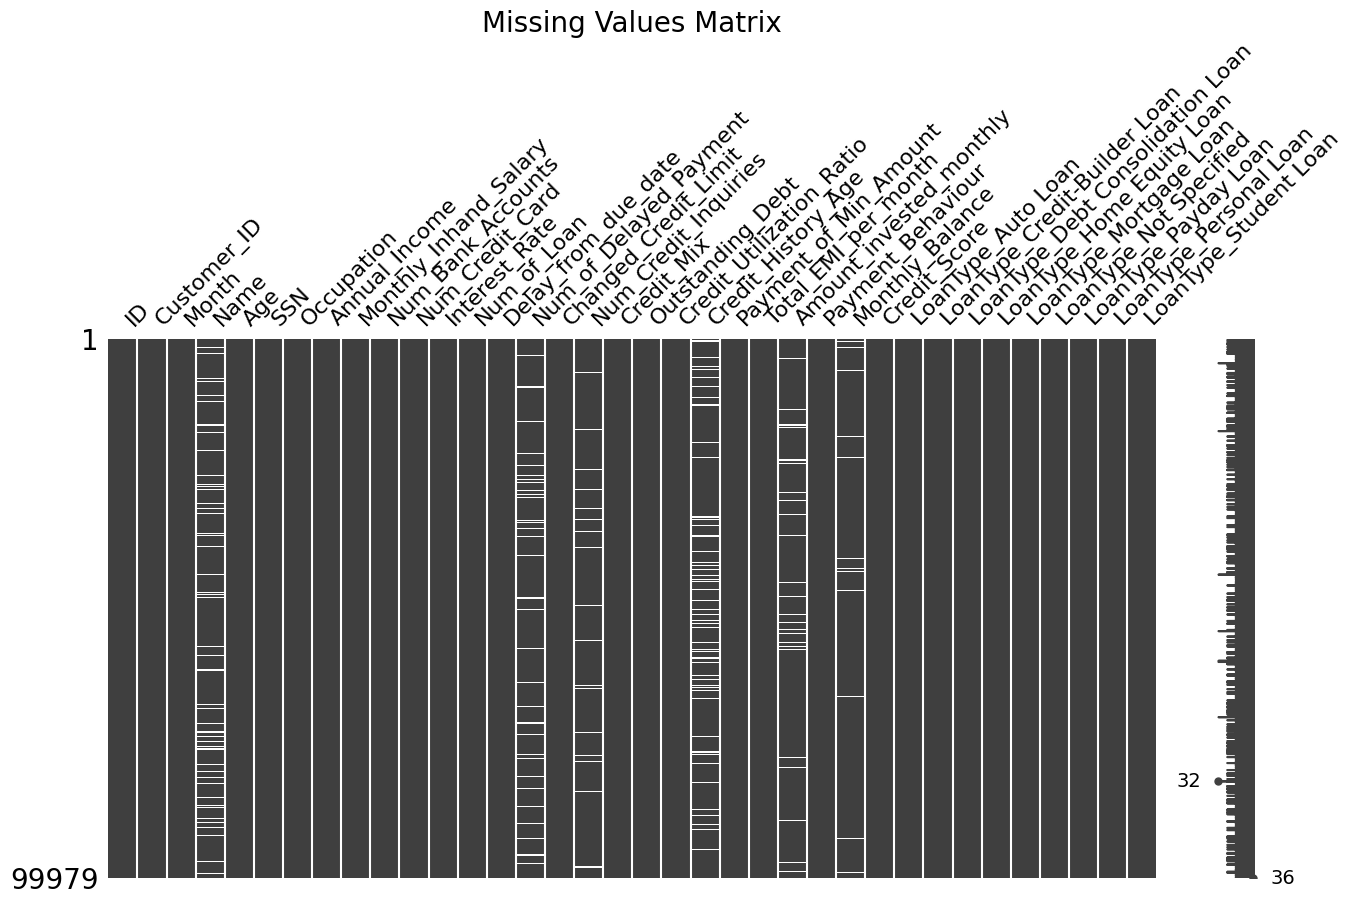

In [76]:
msno.matrix(df, figsize=(15, 7))
plt.title('Missing Values Matrix', fontsize=20)
plt.show()